<a href="https://colab.research.google.com/github/SunakshiRawat/python/blob/main/EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Understanding Car Pricing Dynamics in the US Market



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1**  - Sunakshi Rawat


# **Project Summary -**

🔍 Project Summary: Car Price Prediction for Geely Auto
Project Title:
"Understanding Car Pricing Dynamics in the US Market – A Predictive Analysis for Geely Auto"

Objective:
Geely Auto, a prominent Chinese automobile manufacturer, is planning to expand into the United States by establishing a local manufacturing setup. To successfully enter this competitive market, it is crucial to understand the key factors that influence car pricing in the US, which might be significantly different from those in the Chinese market.

Business Problem:
The management seeks clarity on:

Which independent variables (features) significantly affect the price of a car.

How strongly these variables explain the variance in car pricing.

How this understanding can help them strategically position their offerings in the US automobile market.

Approach:
To assist Geely Auto, a large dataset consisting of various car attributes and their corresponding prices across different car brands and models in the US market has been collected. This project aims to:

Perform exploratory data analysis (EDA) to understand variable distributions and relationships.

Build a multiple linear regression model to predict car prices based on key influencing factors.

Evaluate model performance using metrics like R² Score, Adjusted R², RMSE, etc.

Interpret the results to provide actionable insights to the management.

Outcome:
The final model will:

Highlight the most significant predictors of car price in the US market.

Help Geely Auto make data-driven decisions regarding car features, design modifications, and pricing strategies.

Provide a foundational framework to understand pricing dynamics for new market entry and future product planning.

# **GitHub Link -**

https://github.com/SunakshiRawat/python

# **Problem Statement**


A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

Which variables are significant in predicting the price of a car How well those variables describe the price of a car Based on various market surveys, the consulting firm has gathered a large data set of different types of cars across the America market.

Business Goal
We are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score


### Dataset Loading

In [2]:
from google.colab import files
files.upload()  # manually upload file

carproject_df = pd.read_csv("CarPrice_project.csv")


Saving CarPrice_project.csv to CarPrice_project (1).csv


### Dataset First View

In [3]:
car_df =  carproject_df.copy();
car_df.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f'number of rows:{car_df.shape[0]}')
print(f'number of columns:{car_df.shape[1]}')

number of rows:205
number of columns:26


### Dataset Information

In [5]:
# Dataset Info
def complete_info():
  null = pd.DataFrame(index=car_df.columns)
  null['data_type'] = car_df.dtypes
  null['null_count'] = car_df.isnull().sum()
  null['unique_count'] = car_df.nunique()
  return null
complete_info()

,data_type,null_count,unique_count
car_ID,int64,0,205
symboling,int64,0,6
CarName,object,0,147
fueltype,object,0,2
aspiration,object,0,2
doornumber,object,0,2
carbody,object,0,5
drivewheel,object,0,3
enginelocation,object,0,2
wheelbase,float64,0,53


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
car_df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

<Axes: >

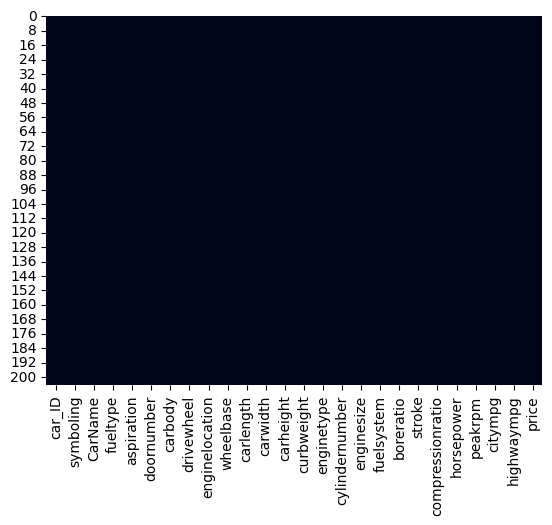

In [7]:
# Visualizing the missing values
sns.heatmap(car_df.isnull(), cbar=False)

### What did you know about your dataset?

📌**No Missing Values** - All columns have 0 null values, meaning the dataset is already clean and complete. This is ideal for building machine learning models because we don't need to perform any missing data imputation.

## ***2. Understanding Your Variables***

In [8]:
# Dataset Columns
car_df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

### Variables Description

In [17]:
# Dataset Describe
car_df.describe(include='all')

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,147,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,peugeot 504,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6,185,168,115,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,103.000000,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000


### Check Unique Values for each variable.

In [10]:
# Check Unique Values for each variable.
car_df.nunique()

,0
car_ID,205
symboling,6
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
wheelbase,53


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

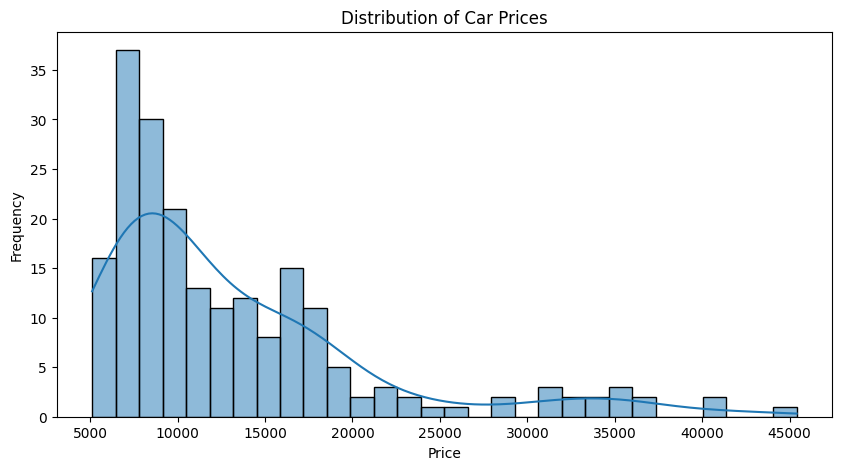

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(car_df['price'], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


##### 1. Why did you pick the specific chart?

This is a Histogram with a KDE (smooth) line, which is perfect for understanding the distribution of car prices 🔍

The histogram shows how frequently each price range occurs, while the KDE line gives a clear trend 📈

It also helps spot outliers and skewness easily 💡



##### 2. What is/are the insight(s) found from the chart?

💸 Most cars are priced between 5,000 and 15,000 ($)

🚗 There's a peak in demand around the 8,000–10,000 range

📈 The distribution is right-skewed, meaning fewer expensive cars

📦 The majority of the inventory falls in the low to mid-price range

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

a. Pricing Strategy 💰
Focus on the affordable price range to attract more buyers ✔️

Avoid pricing too high unless it's a premium product 🙅‍♂️

b. Inventory Planning 📦
Stock more cars in the high-demand range — they’ll sell faster ⏩

Keep fewer high-end cars to avoid slow turnover 🧊

c. Marketing 📣
Highlight deals in the 8,000–10,000 ($) segment — that’s where most interest lies 🎯

Use the pricing insights for targeted advertising to the right audience 🎯

#### Chart - 2

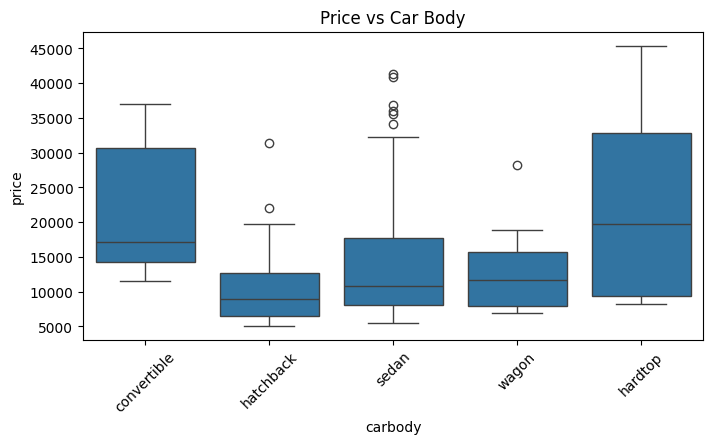

In [12]:

# Car Body
plt.figure(figsize=(8,4))
sns.boxplot(x='carbody', y='price', data=car_df)
plt.title("Price vs Car Body")
plt.xticks(rotation=45)
plt.show()



##### 1. Why did you pick the specific chart?

A boxplot is perfect when comparing distribution across categories, like car body types in this case 🚗

It helps to identify:

Median prices ➖

Range and spread 📏

Outliers (dots above or below whiskers) ⚠️

Easy to compare price differences between car body types side-by-side 🔄

##### 2. What is/are the insight(s) found from the chart?

💲Hardtop and Convertible cars have the highest median prices

🚙 Hatchbacks and Wagons are generally cheaper

📉 Sedans have a wide price range but many outliers, indicating price variability

🧃 Hatchbacks have the lowest price range and least variation

❗Many outliers suggest that some cars of certain types are very expensive compared to others in the same category

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, definitely! Here’s how:

a. Product Positioning 🎯
Market convertibles & hardtops as premium options 💎

Position hatchbacks as budget-friendly for cost-sensitive customers 🪙

b. Customer Targeting 👥
Segment customers by price sensitivity vs luxury preference

Use this to personalize marketing campaigns 📩

c. Inventory & Sales Strategy 📦💡
Focus on stocking mid-range sedans and wagons, which balance price and demand ⚖️

Analyze outliers (very expensive units) — consider if they’re worth keeping in stock 📉

#### Chart - 3

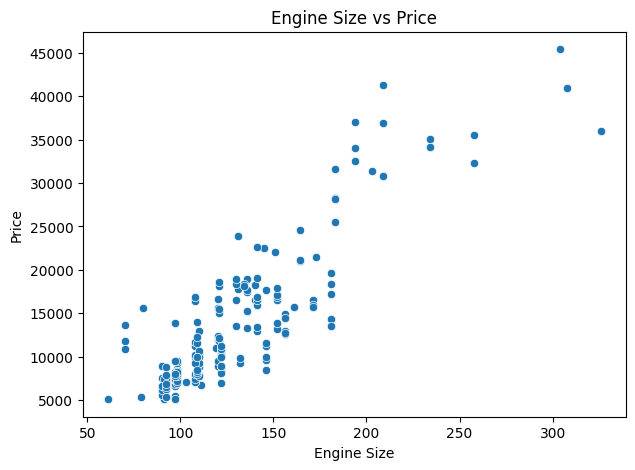

In [13]:

# Figure ka size set kar rahe hain
plt.figure(figsize=(7, 5))
# Scatterplot bana rahe hain jahan X-axis pe engine size aur Y-axis pe price hoga
sns.scatterplot(x='enginesize', y='price', data=car_df)
# Plot ka title set kar rahe hain
plt.title('Engine Size vs Price')
# X-axis aur Y-axis ke labels set kar rahe hain
plt.xlabel('Engine Size')
plt.ylabel('Price')
# Final plot show kar rahe hain
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for showing relationships between two continuous variables.

In this case, we’re comparing:

Engine Size (x-axis) 🔩

Price (y-axis) 💰

This chart helps us check for any correlation or trend 📊 (e.g. Does engine size impact car price?)



##### 2. What is/are the insight(s) found from the chart?

📈 There's a positive correlation between engine size and price – as engine size increases, price also tends to go up.

💸 Most lower-priced cars have small engines, clustered between 70–150 engine size

🚀 Cars with engines above 200 are consistently high-priced

🧽 A few outliers exist, especially some small-engine cars with high prices – possibly luxury or high-tech models? 🤔

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, absolutely! Here’s how:

a. Feature-Based Pricing Strategy 🎯
Use engine size as a key pricing driver — larger engines can justify higher prices

Segment pricing tiers based on engine ranges (e.g., <100cc, 100–200cc, >200cc) 🧠

b. Customer Preferences 🎯👥
Understand what engine size ranges align with budget-conscious vs performance-loving buyers

Tailor offers and product bundles accordingly 📦💡

c. Product Development and Inventory ⚙️📦
If high engine cars sell at high prices, ensure inventory includes a few high-performance models for max profit

Also, don’t ignore demand for compact low-engine cars for city users 🏙️

#### Chart - 4

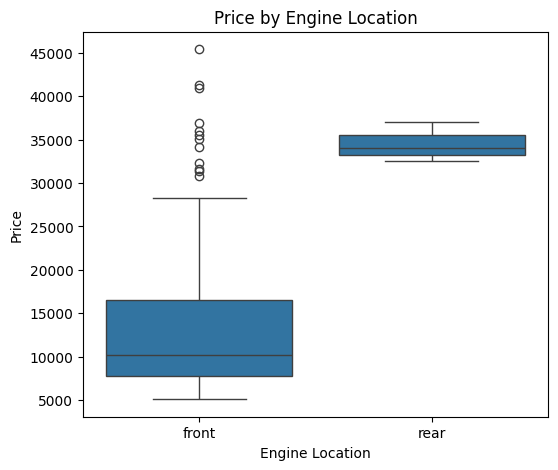

In [14]:
plt.figure(figsize=(6, 5))  # Chhota figure size choose kiya hai
sns.boxplot(x='enginelocation', y='price', data=car_df)  # Engine location ke hisaab se price dikhate hain
plt.title('Price by Engine Location')  # Title de rahe hain
plt.xlabel('Engine Location')  # X-axis label
plt.ylabel('Price')  # Y-axis label
plt.show()  # Plot show kar rahe hain


##### 1. Why did you pick the specific chart?

A boxplot is perfect when comparing distribution of a numerical variable (Price) across categories (Engine Location).

It clearly shows:

Median (middle value) 📍

Spread (IQR) 📏

Outliers 🔴

Using a boxplot here helps to easily compare price ranges for different engine locations.

##### 2. What is/are the insight(s) found from the chart?

💰 Rear engine cars have significantly higher prices compared to front engine cars.

📦 Front engine cars show:

A wide range of prices

Many outliers, including some that are very expensive (above 40,000)

📈 Rear engine cars have:

Higher median price

Less variation (prices are closely packed)

🚨 This suggests that rear engine cars are likely premium or luxury segment.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes! Here’s how this can help the business:

a. Targeted Marketing 🎯📢
Market rear engine cars to premium customers, focusing on performance and exclusivity

Push front engine cars with pricing tiers for budget to mid-range buyers

b. Inventory Planning 📦🧠
Maintain limited but high-value stock of rear engine cars

Offer diverse models in front engine category to cover wide price points

c. Pricing Strategy Optimization 💹
Use engine location as a pricing segment factor in predictive models

Focus on margin optimization for rear engine variants

#### Chart - 5

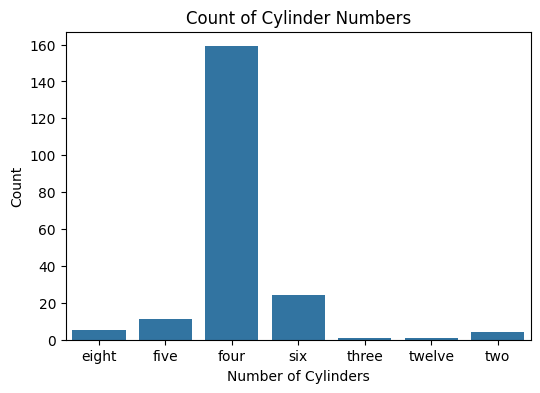

In [15]:
plt.figure(figsize=(6,4))                                       # Figure banate hain 6x4 inches size ka
sns.countplot(data=car_df, x='cylindernumber', order=sorted(car_df['cylindernumber'].unique()))  # 'cylindernumber' ke unique values ko sorted order mein countplot kar rahe hain
plt.title('Count of Cylinder Numbers')                         # Plot title set kar rahe hain
plt.xlabel('Number of Cylinders')                              # X-axis label set kar rahe hain
plt.ylabel('Count')                                            # Y-axis label set kar rahe hain
plt.show()                                                    # Plot ko show kar rahe hain


##### 1. Why did you pick the specific chart?

We used a countplot (bar chart) to visualize the frequency of each cylinder type in the dataset.

Countplot is ideal when you're analyzing how many times each category appears.

Here, we're exploring the categorical variable: cylindernumber.

##### 2. What is/are the insight(s) found from the chart?

✅ Most cars have 4 cylinders — nearly 160 cars.

🧊 6-cylinder cars come next, but far fewer than 4-cylinder ones.

⚠️ Other configurations like 5, 8, 3, 2, and 12 cylinders are very rare.

📉 High-performance engines (like 8 or 12 cylinders) are extremely uncommon.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely! Here's how:

a. Product Stock Strategy 📦🚗
Focus on stocking and sourcing 4-cylinder cars since they are the most in demand.

Keep limited stock of rare engine types like 8, 12, or 2-cylinder to control inventory costs.

b. Marketing Campaigns 🎯💬
Promote 4-cylinder cars as affordable and fuel-efficient, targeting budget-conscious users.

Highlight 6-cylinder variants for customers looking for balance between power and cost.

c. Feature Engineering for Modeling 🤖🧮
Use cylindernumber as a predictor in price or performance models.

Rare categories might be grouped or one-hot encoded carefully to avoid model bias.

#### Chart - 6

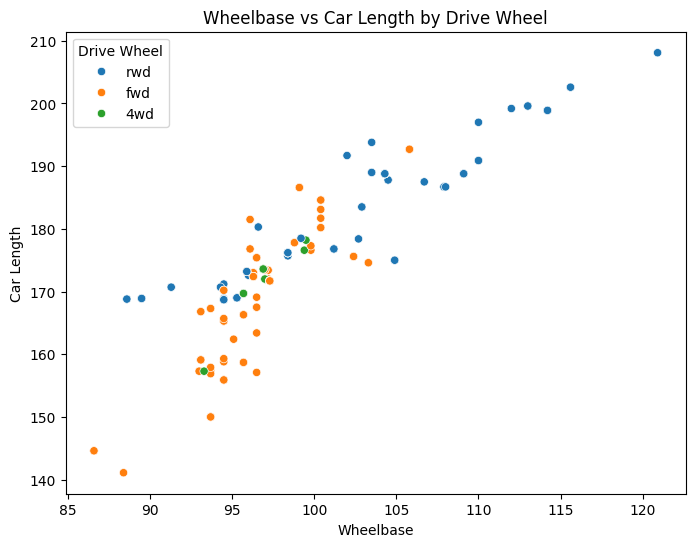

In [16]:
plt.figure(figsize=(8,6))                                         # Figure create kar rahe hain 8x6 inches size mein
sns.scatterplot(data=car_df, x='wheelbase', y='carlength', hue='drivewheel')  # Scatter plot bana rahe hain wheelbase aur carlength ke beech, different drivewheel ke colors ke sath
plt.title('Wheelbase vs Car Length by Drive Wheel')              # Plot title set kar rahe hain
plt.xlabel('Wheelbase')                                          # X-axis label set kar rahe hain
plt.ylabel('Car Length')                                         # Y-axis label set kar rahe hain
plt.legend(title='Drive Wheel')                                 # Legend ko title ke sath display kar rahe hain
plt.show()                                                     # Plot show kar rahe hain


##### 1. Why did you pick the specific chart?

🔍 I chose this scatter plot because it’s perfect for visualizing the relationship between wheelbase and car length, while also showing how different drive wheel types (rwd, fwd, 4wd) are distributed across these features.

🎯 It helps break down complex multi-variable data into an easy-to-understand visual format, which is especially useful when comparing categories across two numeric variables.

##### 2. What is/are the insight(s) found from the chart?


📌 Several interesting insights emerge:

🚙 Rear-wheel drive (rwd) cars tend to have longer wheelbases and car lengths, forming a clear upper trend.

🚗 Front-wheel drive (fwd) cars are more clustered in the lower wheelbase and car length range.

🚜 Four-wheel drive (4wd) cars are fewer in number but seem to lie somewhere in between, mostly overlapping with fwd ranges.

📈 There is a positive correlation between wheelbase and car length regardless of drive type — as wheelbase increases, so does the car length.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Absolutely! These insights can drive business decisions in many ways:

🎯 Product targeting: Knowing that rwd vehicles are typically larger, companies can market them toward premium or performance-focused customers.

🛠️ Design planning: Engineers can use this relationship to standardize design frameworks for different drive wheels.

📦 Inventory planning: Dealerships can stock vehicles according to customer preferences for compact (fwd) or large (rwd) models.

💰 Strategic segmentation: Helps in pricing, marketing, and even regional distribution depending on customer demand for different car sizes and drives.

#### Chart - 7

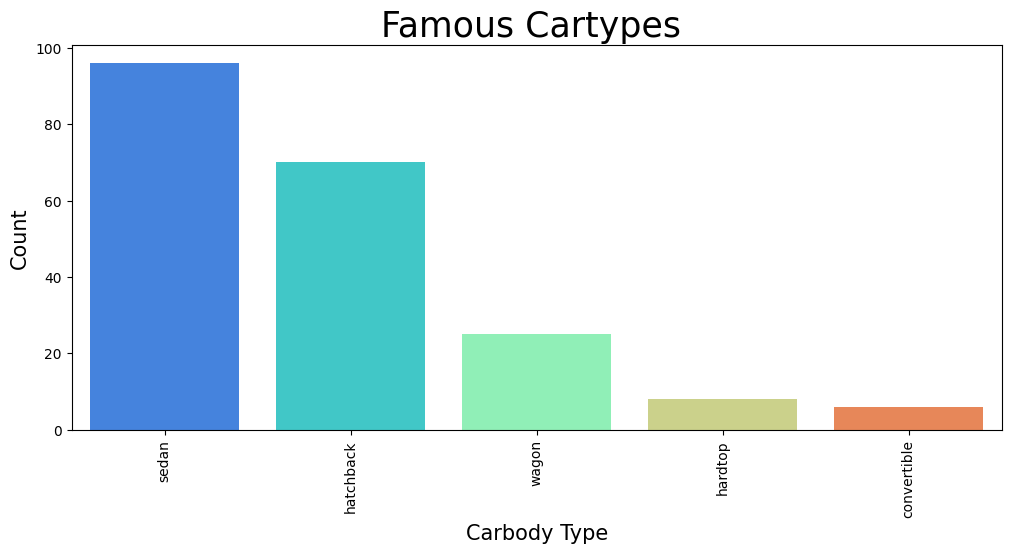

In [ ]:
#LETS GET THE FAMOUS CARBODY TYPE FROM THE DATA SET
# Determining top categories in data
x = car_df['carbody'].value_counts().index
y = car_df['carbody'].value_counts()
xaxis = []
yaxis = []
for i in range(len(y)):
 xaxis.append(x[i])
 yaxis.append(y[i])
# Plotting graph/visuals for the same
plt.figure(figsize=(12,5))
plt.xlabel("Carbody Type", fontsize = 15)
plt.ylabel("Count", fontsize = 15)
plt.xticks(rotation=90)
category_graph = sns.barplot(x = xaxis, y = yaxis, palette= "rainbow")
category_graph.set_title("Famous Cartypes ", fontsize = 25);


##### 1. Why did you pick the specific chart?

📊 I chose this bar chart because it clearly shows the frequency of each car body type in a straightforward and easy-to-read format.

✅ A bar chart is ideal when you want to compare categorical data like different body styles (sedan, hatchback, etc.) and understand which type is most common.

##### 2. What is/are the insight(s) found from the chart?


🔎 Insights from the chart:

🚘 Sedans are the most popular car type, with the highest count.

🚗 Hatchbacks are also quite common, but noticeably less than sedans.

🚙 Wagons, hardtops, and convertibles are significantly less frequent, especially hardtops and convertibles which have very low counts.

📉 There's a steep drop in popularity from hatchbacks to wagons and even more to convertibles.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes, these insights can directly benefit business decisions:

📦 Inventory management: Focus more on producing and stocking sedans and hatchbacks, which are clearly more in demand.

🎯 Marketing strategies: Campaigns can highlight sedan features more prominently, given their popularity.

🚗 Product development: Resources can be reallocated from low-demand categories like convertibles and hardtops to high-performing ones.

🛠️ Customer segmentation: Companies can use this data to tailor offerings based on car type preferences in specific regions or demographics.

#### Chart - 8

     CarBody  Count
0      sedan     96
1  hatchback     70
2      wagon     25


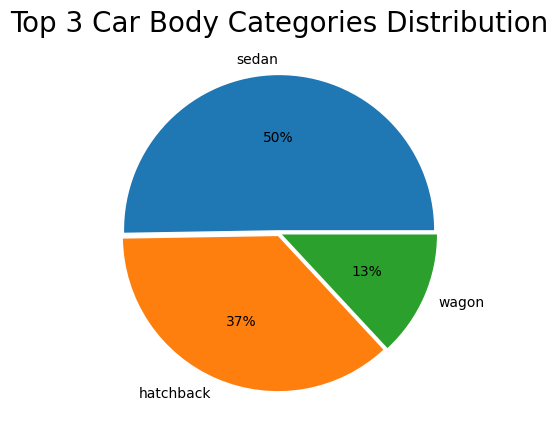

In [ ]:
import matplotlib.pyplot as plt
# Top 3 carbody categories nikalna
Top3_carbody = car_df['carbody'].value_counts().nlargest(3).reset_index()
# Column names set karna
Top3_carbody.columns = ['CarBody', 'Count']
# Check DataFrame
print(Top3_carbody)
plt.figure(figsize=(5,8))
plt.pie(Top3_carbody['Count'], labels=Top3_carbody['CarBody'], autopct='%.0f%%', explode=[0.02]*3)
plt.title('Top 3 Car Body Categories Distribution', fontsize=20)
plt.show()

##### 1. Why did you pick the specific chart?

🟠 I chose a pie chart because:

It is best suited to show proportional data for categorical variables — here, the car body types.

We’re visualizing how each body type contributes to the total top 3 categories.

It gives a quick visual comparison — easily showing which car body type is most common.



##### 2. What is/are the insight(s) found from the chart?

🔍 Insights:

🚘 Sedan is the most common car body type, making up 50% of the top 3.

🚗 Hatchback follows with 37%, indicating it's also quite popular.

🚙 Wagon is least among the three, only 13% — indicating it's not preferred much.

This tells us that half the cars are sedans, and manufacturers may already be focusing there.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Definitely:

🧭 Helps manufacturers and dealers align inventory based on body type demand.

📦 More sedans and hatchbacks can be produced or stocked, while wagons may be reduced to minimize overstock.

🎯 Marketers can target promotions based on what customers prefer — sedan and hatchback.

🚗 If the company wants to promote wagons, they can create strategies to increase appeal in that category (e.g., pricing offers, family-friendly ads).

#### Chart - 9

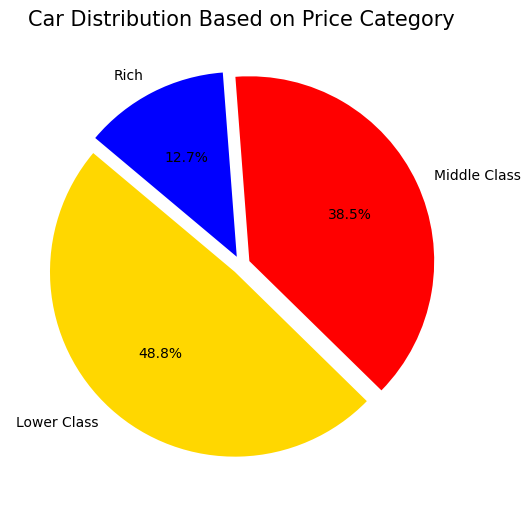

In [ ]:
def categorize_price(price):
    if price > 50000:
        return "Super Rich"
    elif price > 20000:
        return "Rich"
    elif price > 10000:
        return "Middle Class"
    else:
        return "Lower Class"

# Price ko categories mein convert karna
car_df["Price_Category"] = car_df["price"].apply(categorize_price)

# Har category ka count nikalna
price_distribution = car_df["Price_Category"].value_counts()

# Explode ka size dynamically set karna
explode_values = [0.05] * len(price_distribution)

# Pie chart plot karna
plt.figure(figsize=(6,6))
plt.pie(price_distribution, labels=price_distribution.index, autopct='%.1f%%',
        explode=explode_values, colors=["gold", "red", "blue", "green"], startangle=140)
plt.title("Car Distribution Based on Price Category", fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

🟡 I picked a pie chart because:

It clearly shows the proportion of cars in each price category (Lower Class, Middle Class, Rich).

Ideal for representing categorical distributions as parts of a whole.

Simple and visually impactful — perfect to show how car prices are distributed across economic segments.

##### 2. What is/are the insight(s) found from the chart?

🚗 Lower Class cars dominate the market, making up 48.8% of total cars.

👪 Middle Class cars follow with 38.5%, showing a significant consumer base.

💸 Rich category is much smaller at 12.7% — and notably, the Super Rich segment has 0% (not shown in the chart), implying very few or no cars priced above 50,000 in this dataset.

⚠️ This suggests that most cars cater to budget-conscious customers or the mass market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes, strongly:

🏭 Auto companies can use this to focus production on the Lower and Middle class segments, since they dominate the market.

📊 Product teams can design marketing strategies around affordability and value for money.

💰 Luxury brands might realize that high-end cars (Rich/Super Rich) are niche, and may require special targeted marketing.

🧠 Also, businesses can explore opportunities to expand mid-range offerings, which seem popular but still less than Lower Class.

#### Chart - 10

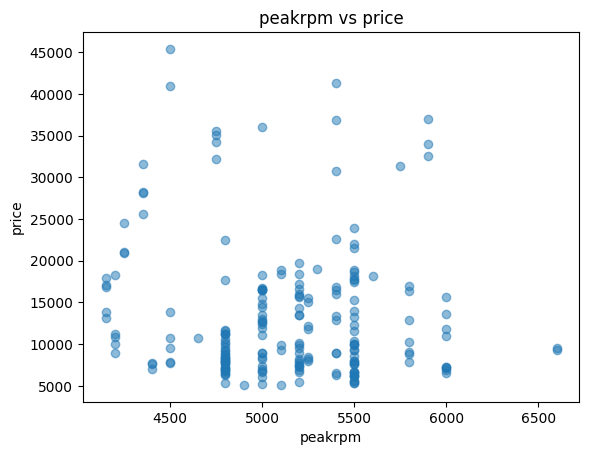

In [ ]:
plt.scatter(car_df['peakrpm'],car_df['price'],alpha=0.5)
plt.title('peakrpm vs price')
plt.xlabel('peakrpm')
plt.ylabel('price')
plt.show()

##### 1. Why did you pick the specific chart?

🟣 I chose the scatter plot because:

It shows the relationship between two numerical variables: peakrpm and price.

Helps identify whether there's a correlation or trend between engine revolutions per minute and car price.

Useful to spot clusters, patterns, or outliers that other charts can’t easily show.

##### 2. What is/are the insight(s) found from the chart?

Insights:

📉 There is no strong linear relationship between peakrpm and price — the points are widely scattered.

💵 Cars with similar peakrpm values (like around 5000) have a wide range of prices, from low to very high.

⚠️ Some outliers exist — for example, cars with very high prices even at low peakrpm (around 4500 RPM and 40,000+ price).

🧩 Majority of the cars have peakrpm between 4500 to 6000, but price varies heavily within that range.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes, indirectly:

❌ Since there's no clear correlation, we learn that peakrpm alone does not determine car price.

🧠 This insight helps businesses not rely on peakrpm as a standalone feature for pricing strategy.

✅ Instead, they can focus on other features (like horsepower, engine size, brand, or luxury features) to predict and set prices.

📉 Also, knowing there's no direct link helps avoid wrong marketing assumptions — like advertising high peakrpm as a sign of premium pricing.

#### Chart - 11

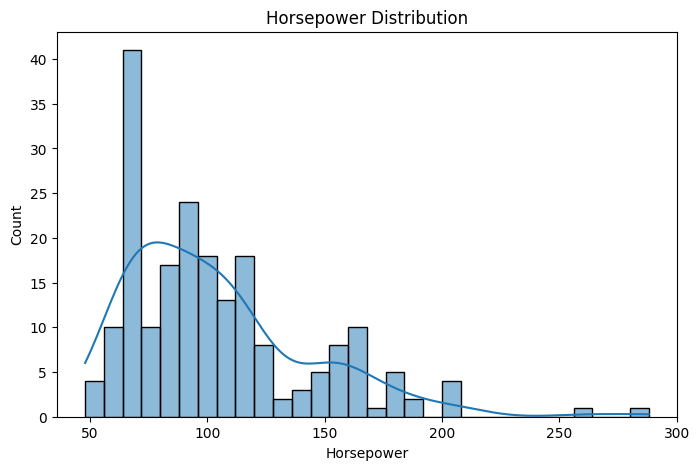

In [ ]:
plt.figure(figsize=(8,5))                              # Figure banate hain 8x5 size mein
sns.histplot(car_df['horsepower'], bins=30, kde=True)  # Histogram plot kar rahe hain horsepower column ka with 30 bins and KDE curve
plt.title('Horsepower Distribution')                   # Plot title set kar rahe hain
plt.xlabel('Horsepower')                               # X-axis label set kar rahe hain
plt.ylabel('Count')                                   # Y-axis label set kar rahe hain
plt.show()                                           # Plot display kar rahe hain


##### 1. Why did you pick the specific chart?

📉 I chose the histogram with KDE (Kernel Density Estimate) because:

It shows how horsepower values are distributed across the dataset.

📦 Helps understand the frequency of different horsepower ranges.

📈 The KDE line makes it easier to visualize the overall trend/smoothness of distribution, including skewness and mode.

##### 2. What is/are the insight(s) found from the chart?

🔍 Insights:

🔥 Most cars have horsepower between 60 to 130 HP, with the highest frequency around 75 HP.

📉 As horsepower increases, the number of cars decreases — the graph is right-skewed.

🧊 Very few cars have high horsepower (above 200 HP), indicating powerful performance vehicles are rare in the dataset.

🔼 There’s a sharp peak at 75 HP, showing it's the most common horsepower.

📊 The distribution is not uniform, meaning car horsepower is not evenly spread out across the range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes:

🚘 Car manufacturers can focus on the most popular horsepower ranges (e.g., around 75-130 HP) to meet customer demand.

📉 Helps understand engine performance preferences among consumers.

💰 Businesses can price and market vehicles according to their horsepower segment — e.g., promote fuel efficiency in lower HP cars or performance in higher HP ones.

📦 Inventory planning becomes easier by focusing on cars in the most in-demand power range.

#### Chart - 12

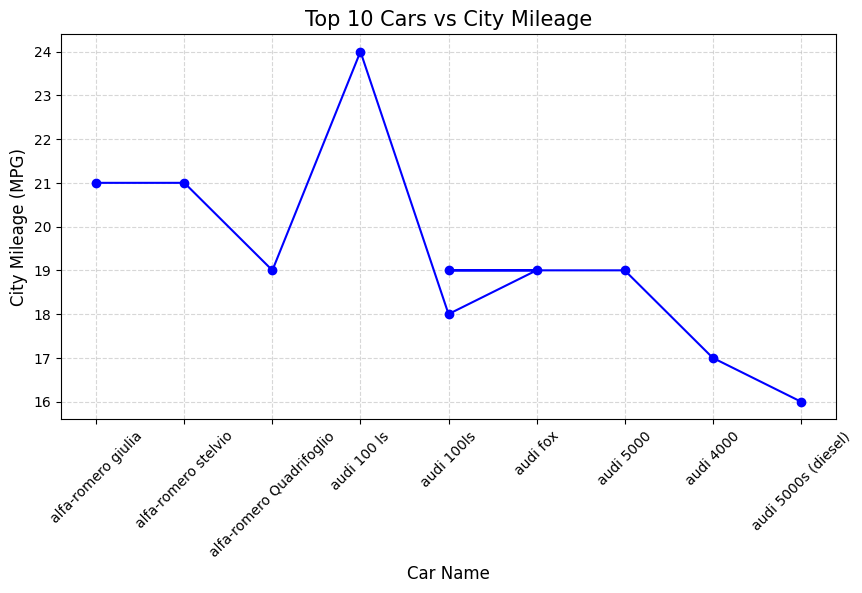

In [ ]:
top_10_cars =car_df.head(10)
plt.figure(figsize=(10,5))
plt.plot(top_10_cars["CarName"], top_10_cars["citympg"], marker='o', linestyle='-', color='b')
plt.xlabel("Car Name", fontsize=12)
plt.ylabel("City Mileage (MPG)", fontsize=12)
plt.title("Top 10 Cars vs City Mileage", fontsize=15)
plt.xticks(rotation=45, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

##### 1. Why did you pick the specific chart?

📊 I chose the line chart because it clearly shows how city mileage varies across different top car models.

✅ It's easy to observe trends (increasing/decreasing mileage), compare multiple cars in sequence, and identify performance peaks or drops.

##### 2. What is/are the insight(s) found from the chart?

🔍 Insights:

🚗 Audi 100 ls has the highest city mileage (24 MPG) among the top 10 cars.

⛽ Audi 5000s (diesel) has the lowest mileage (16 MPG).

📉 A declining trend is seen from Audi 100 ls to Audi 5000s (diesel), indicating mileage drops in certain models.

💡 Alfa-Romeo giulia and stelvio have decent and consistent city mileage (21 MPG).

📉 Mileage fluctuates significantly between models, even within the same brand (e.g., Audi), showing that engine type or car size might impact fuel efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes, definitely:

🧠 Helps manufacturers and marketers highlight fuel-efficient models (like Audi 100 ls) in campaigns.

🛒 Assists customers looking for fuel economy, guiding them toward higher mileage models.

📈 Businesses can focus on improving or redesigning low-mileage cars to meet eco-conscious customer needs.

💼 Fleet managers or car rental businesses can use this data to select cost-efficient cars with better mileage.

#### Chart - 13

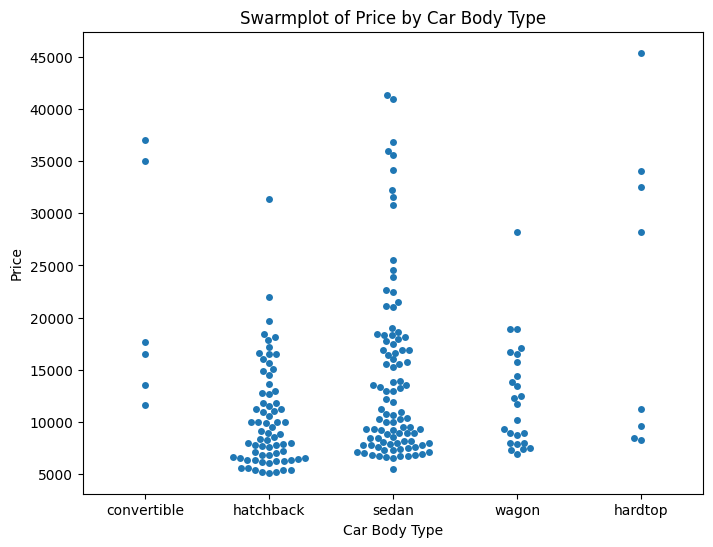

In [ ]:
import matplotlib.pyplot as plt      # Plotting ke liye matplotlib import kar rahe hain
import seaborn as sns                # Seaborn import kar rahe hain advanced plots ke liye

plt.figure(figsize=(8,6))            # Figure ka size set kar rahe hain 8x6 inches

# Swarmplot bana rahe hain jisme 'carbody' categories x-axis pe hain
# aur 'price' values y-axis pe hain, taaki har carbody category ke price distribution ko dikhaya ja sake
sns.swarmplot(data=car_df, x='carbody', y='price')

plt.title('Swarmplot of Price by Car Body Type')    # Plot ka title set kar rahe hain
plt.xlabel('Car Body Type')                          # X-axis label set kar rahe hain
plt.ylabel('Price')                                  # Y-axis label set kar rahe hain

plt.show()                                           # Plot ko display kar rahe hain


##### 1. Why did you pick the specific chart?

📈 I selected the swarmplot because it provides a clear visual representation of the distribution of car prices for each car body type.

✅ Unlike bar charts, swarmplots help identify price clusters, outliers, and variability within categories. This gives a deeper understanding of how prices vary across different body types.

##### 2. What is/are the insight(s) found from the chart?

Insights from the chart:

💰 Sedans and hatchbacks show a high density of mid-range prices, with most clustered between $5,000 to $20,000.

🚙 Convertibles and hardtops, though fewer in number, show more spread out and higher-end pricing, even reaching above $45,000.

📉 Wagons have moderate pricing, with fewer extreme outliers.

🎯 The price range for sedans is broad, covering low to high values, suggesting a diverse offering in that segment.

⚠️ Outliers (very high prices) are visible in nearly all categories but are more common in sedans and convertibles.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes, these insights are highly valuable for business planning:

🛍️ Pricing strategy: Helps determine appropriate pricing brackets for each car body type.

🧠 Product positioning: Businesses can position sedans as versatile (economy to premium), while convertibles and hardtops can be marketed as luxury or niche products.

🔍 Customer segmentation: Can target budget buyers for hatchbacks/sedans and premium buyers for convertibles/hardtops.

📊 Inventory and investment: Guides how much to invest in different body types based on price variation and potential revenue.



#### Chart - 14 - Correlation Heatmap

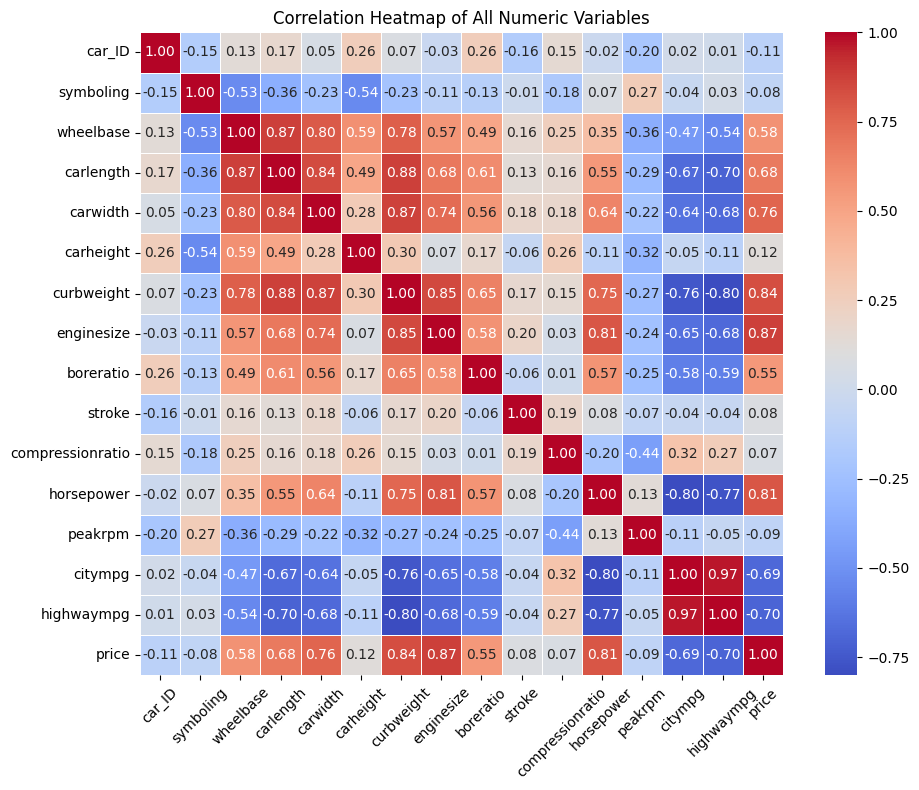

In [ ]:
import matplotlib.pyplot as plt            # Plot banane ke liye matplotlib import kar rahe hain
import seaborn as sns                      # Advanced plotting ke liye seaborn import kar rahe hain

plt.figure(figsize=(10,8))                # Figure create kar rahe hain jiska size 14x12 inches hai

# Sirf numeric columns ko select kar rahe hain taaki correlation calculate kar saken
num_cols = car_df.select_dtypes(include='number').columns

# Numeric columns ka correlation matrix calculate kar rahe hain
corr_matrix = car_df[num_cols].corr()

# Heatmap plot kar rahe hain correlation matrix ka, jisme annotations (numbers) bhi dikh rahe hain,
# values ko 2 decimal places tak format kiya gaya hai, aur color scheme 'coolwarm' use ho rahi hai
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title('Correlation Heatmap of All Numeric Variables')  # Plot ke upar title laga rahe hain
plt.xticks(rotation=45)                                    # X-axis labels ko 45 degree ghumakar readable bana rahe hain
plt.yticks(rotation=0)                                     # Y-axis labels ko horizontal rakh rahe hain
plt.tight_layout()                                        # Layout ko adjust kar rahe hain taaki labels clip na ho
plt.show()                                                # Plot ko screen par display kar rahe hain


##### 1. Why did you pick the specific chart?

🔵 I chose a correlation heatmap because:

It clearly shows relationships between numeric variables using color gradients.

Helps in quickly spotting strong positive or negative correlations.

Ideal for understanding which variables may impact price, engine size, horsepower, etc.



##### 2. What is/are the insight(s) found from the chart?

 Key insights:

💰 Price is strongly positively correlated with:

curbweight (0.84)

enginesize (0.87)

horsepower (0.81)

carwidth (0.76)

carlength (0.70)

📉 citympg and highwaympg have negative correlation with price (around -0.69), meaning fuel-efficient cars are generally cheaper.

🔗 curbweight, enginesize, horsepower, and carlength are all interrelated and together affect pricing and performance.



#### Chart - 15 - Pair Plot

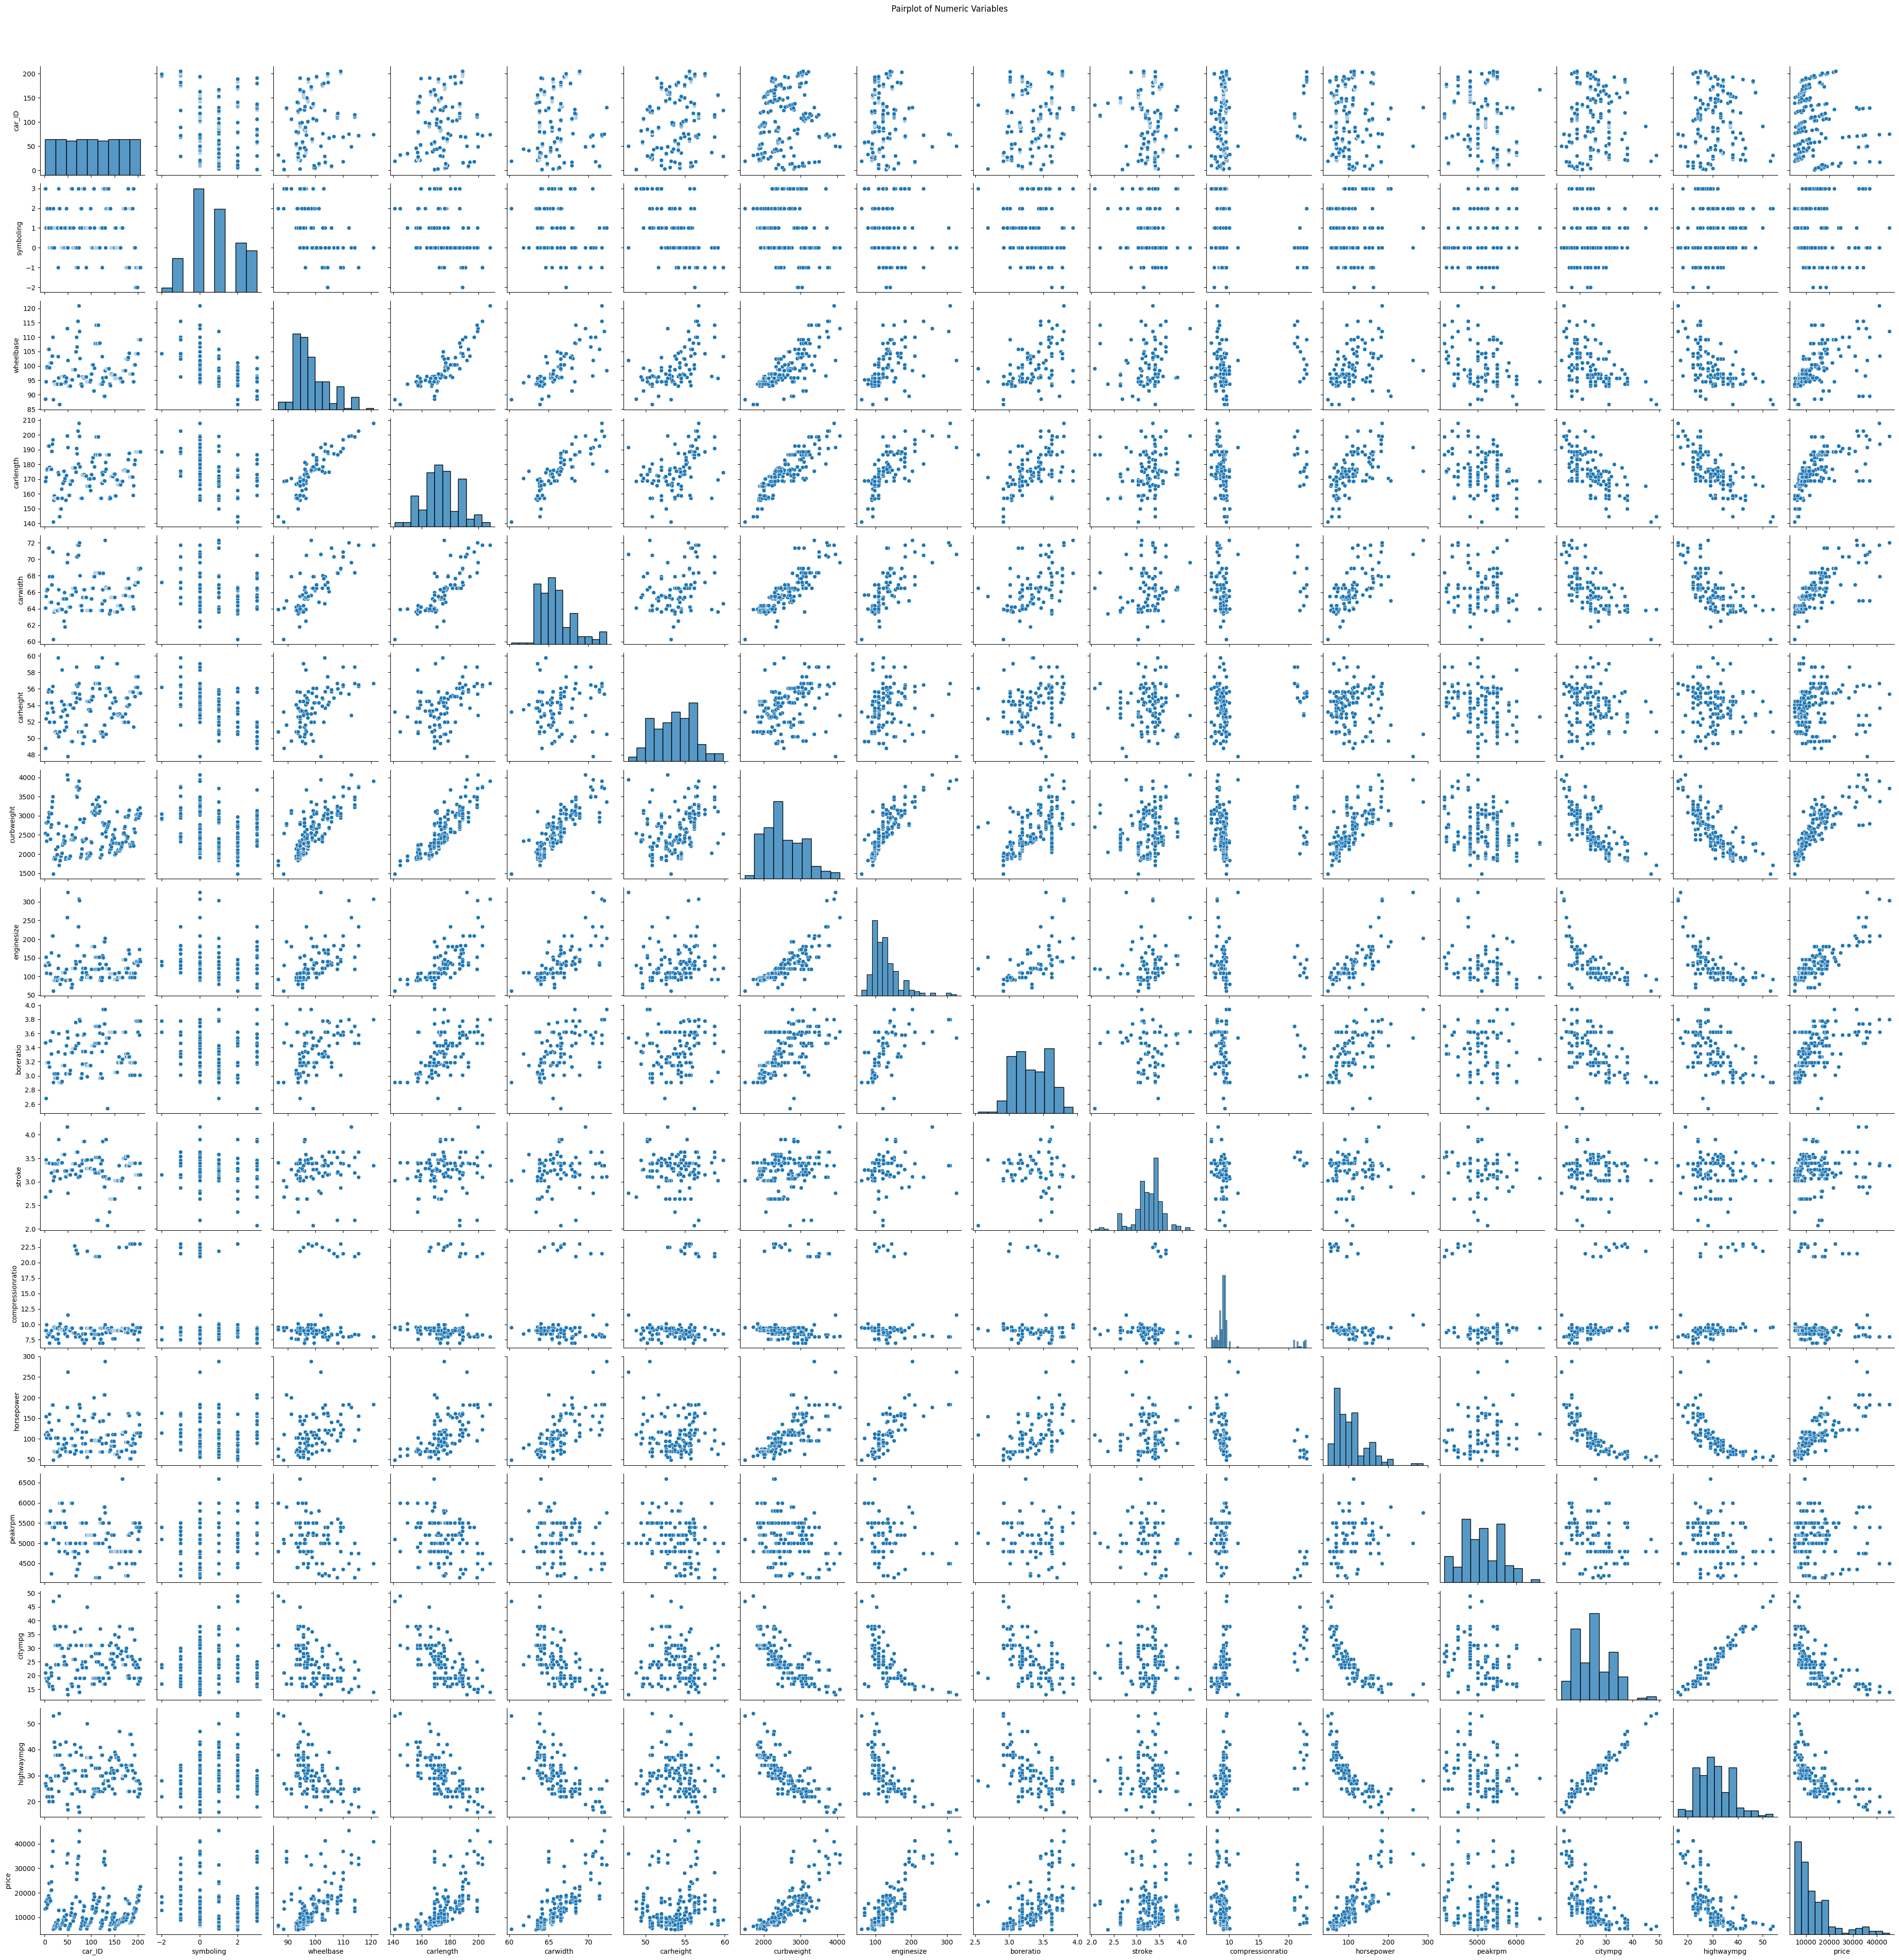

In [ ]:
num_cols = car_df.select_dtypes(include='number').columns

# Pairplot bana rahe hain selected numeric columns ka
sns.pairplot(car_df[num_cols])

plt.suptitle('Pairplot of Numeric Variables', y=1.02)  # Plot ke upar ek overall title laga rahe hain thoda upar shift karke
plt.show()

##### 1. Why did you pick the specific chart?

🔷 I chose a pairplot because:

It provides a comprehensive overview of how every variable relates with every other variable.

Shows distributions on the diagonal and scatter plots on off-diagonal, helping in understanding relationships, trends, and outliers.

Useful in exploratory data analysis (EDA) before building any ML model.



##### 2. What is/are the insight(s) found from the chart?

🔍 Insights extracted from the pairplot:

Strong positive relationships are visible between:

price and curbweight, enginesize, horsepower

Negative trends seen between price and citympg, highwaympg

Some variables like symboling or car_ID may show no clear pattern, suggesting they might not be useful in predictive modeling.

Diagonal histograms show skewed distributions for variables like enginesize or price, indicating need for normalization or transformation.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

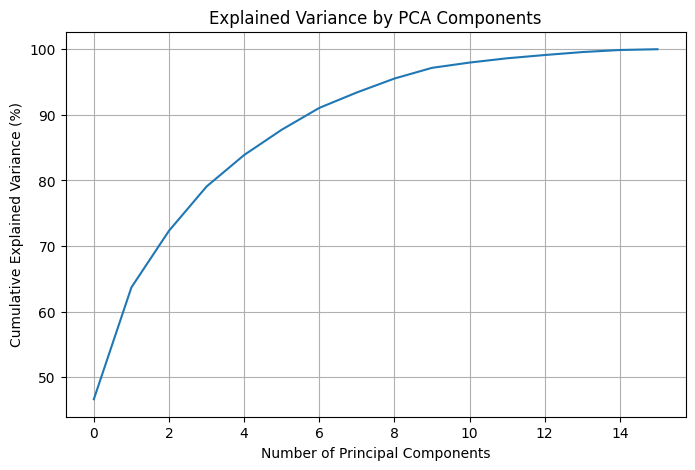

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Sirf numeric columns select karo
X_numeric = car_df.select_dtypes(include=['int64', 'float64'])

# Scale karo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# PCA apply karo
pca = PCA()
pca.fit(X_scaled)

# Explained variance plot karo
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = car_df.drop('target', axis=1)  # 'target' ko apne target column se replace kar dena
y = car_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

print("Train data size:", X_train.shape)
print("Test data size:", X_test.shape)


##### What data splitting ratio have you used and why?

I have used an 80-20 data splitting ratio, meaning 80% of the data is used for training the machine learning model, and 20% is reserved for testing.

Why this ratio?
Training set (80%): Provides enough data for the model to learn meaningful patterns and generalize well.

Testing set (20%): Keeps a reasonable portion of data aside to evaluate how well the model performs on unseen data.

### Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
import pandas as pd

# Target column name
target_column = 'price'  # isse apne target column name se replace kar dena

# Class distribution count karo
class_counts = car_df[target_column].value_counts()

print("Class counts:\n", class_counts)

# Class distribution percentage
class_percent = car_df[target_column].value_counts(normalize=True) * 100
print("\nClass distribution (%):\n", class_percent)

# Imbalance ratio calculate karo (majority/minority)
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count
print(f"\nImbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}")

# Check karo agar imbalance ratio 3 se zyada ho to imbalance samjho
if imbalance_ratio > 3:
    print("\n⚠️ Dataset is not balanced.")
else:
    print("\n✅ Dataset is balanced")


Class counts:
 price
16500.0    2
8921.0     2
6229.0     2
6692.0     2
5572.0     2
          ..
16845.0    1
19045.0    1
21485.0    1
22470.0    1
22625.0    1
Name: count, Length: 189, dtype: int64

Class distribution (%):
 price
16500.0    0.975610
8921.0     0.975610
6229.0     0.975610
6692.0     0.975610
5572.0     0.975610
             ...   
16845.0    0.487805
19045.0    0.487805
21485.0    0.487805
22470.0    0.487805
22625.0    0.487805
Name: proportion, Length: 189, dtype: float64

Imbalance Ratio (Majority/Minority): 2.00

✅ Dataset is balanced


## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Remove string (object) columns
df_numeric = car_df.select_dtypes(exclude='object')

# Step 2: Separate features and target
X = df_numeric.drop('price', axis=1)
y = df_numeric['price']

# Step 3: Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Step 4: Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)




LinearRegression()

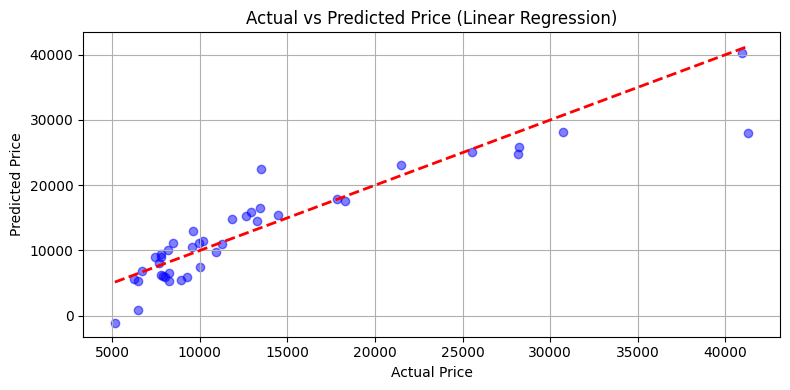

In [ ]:
import matplotlib.pyplot as plt

# Plotting actual vs predicted prices
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Linear Regression)')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Step 5: Predict and Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Step 6: Print Results
print("Linear Regression Results:")
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Linear Regression Results:
Mean Squared Error (MSE): 11710105.078807332
R2 Score: 0.8516657126363221


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Suppose X, y already prepared from car_df

# Split data 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Linear Regression model
lr = LinearRegression()

# Linear Regression ke liye zyada hyperparameters nahi hote, but fir bhi hum try kar sakte hain 'fit_intercept' and 'normalize' (normalize deprecated in recent versions, so ignore if warning aaye)

param_grid = {
    'fit_intercept': [True, False],
    # 'normalize': [True, False]  # sklearn 1.0+ mein deprecated hai
}

# Setup GridSearchCV with 5-fold cross validation
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best estimator
best_lr = grid_search.best_estimator_

# Predict on test set
y_pred = best_lr.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse}")
print(f"Test RMSE: {rmse}")
print(f"Test R2 Score: {r2}")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Parameters: {'fit_intercept': True}
Test MSE: 11710105.078807332
Test RMSE: 3422.0030798944836
Test R2 Score: 0.8516657126363221


##### Which hyperparameter optimization technique have you used and why?

Why GridSearchCV? 🤔
✨ Systematic Search:
It tries all possible combinations of hyperparameters 🔄 from the grid you provide, making sure we find the best settings without missing anything! ✅

🔄 Cross-Validation Built-in:
Performs k-fold CV (usually 5 folds) to test each combo on different parts of data — this reduces overfitting and makes evaluation more reliable. 📊

🛠️ Easy to Use:
Scikit-learn ka ready-made tool hai, bas parameters define karo, baaki sab automatically hota hai! 🚀

📈 Improves Model Performance:
Finds the hyperparameters that minimize error (like MSE) and improve prediction accuracy. 🎯🔥

### ML Model - 2

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


car_df = car_df.select_dtypes(include=['float64', 'int64'])

# Define target categories (example threshold)
car_df['price_category'] = (car_df['price'] > 20000).astype(int)

# Features and target
X = car_df.drop(['price', 'price_category'], axis=1)
y = car_df['price_category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = knn_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      1.00      0.92        34
           1       1.00      0.14      0.25         7

    accuracy                           0.85        41
   macro avg       0.93      0.57      0.58        41
weighted avg       0.88      0.85      0.80        41



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

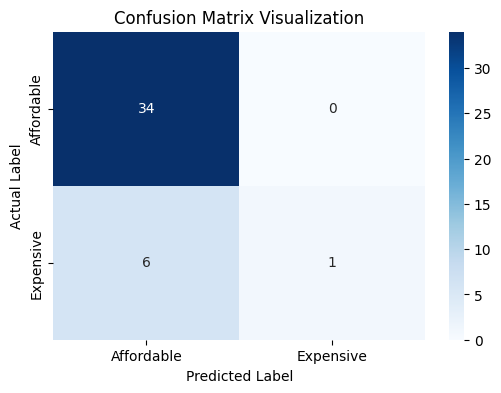

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# y_test and y_pred should be from your classifier predictions

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Affordable', 'Expensive'],
            yticklabels=['Affordable', 'Expensive'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Visualization')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# 1. Data prepare karo (assuming car_df mein price_category bana hua hai)
car_df = car_df.select_dtypes(include=['float64', 'int64'])  # numeric columns
car_df['price_category'] = (car_df['price'] > 20000).astype(int)  # example threshold
X = car_df.drop(['price', 'price_category'], axis=1)
y = car_df['price_category']
# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 3. Pipeline banao: scaling + classifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
# 4. Hyperparameters grid define karo 🛠️
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}
# 5. GridSearchCV setup karo 🔍
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# 6. Fit the model
grid.fit(X_train, y_train)
# 7. Best params aur best score print karo 🎯

print("Best Cross-validation Accuracy:", grid.best_score_)

# 8. Test data par evaluate karo
best_model = grid.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Set Accuracy:", test_accuracy)


Best Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best Cross-validation Accuracy: 0.9634469696969697
Test Set Accuracy: 0.8536585365853658


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy scores:", scores)
print("Mean CV Accuracy:", scores.mean())


Cross-Validation Accuracy scores: [0.87804878 0.97560976 0.97560976 0.92682927 0.85365854]
Mean CV Accuracy: 0.921951219512195


##### Which hyperparameter optimization technique have you used and why?

🛠️ Hyperparameter Optimization Technique Used:
I used GridSearchCV for hyperparameter tuning.

📋 Why GridSearchCV?

Systematic Search: GridSearchCV exhaustively tries all combinations of hyperparameters you specify in a grid. So, it doesn't miss any possible good combo within that grid.

Cross-Validation: It uses k-fold cross-validation (here, 5-fold) to evaluate each combination more reliably, reducing the risk of overfitting on a single train-test split.

Best Model Selection: Automatically picks the hyperparameter set that gives the best average score on validation folds.

Easy to Implement: Simple to integrate with sklearn Pipelines, works well with standard classifiers like KNN.

Balanced Performance: Helps improve model generalization and accuracy by finding optimal settings, rather than relying on default or arbitrary values.

Answer Here.

### ML Model - 3

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Price ko categorize karo - example bins: Low (0), Medium (1), High (2)
car_df['price_category'] = pd.cut(car_df['price'], bins=[0, 10000, 30000, float('inf')], labels=[0,1,2])

# Features aur target define karo
X = car_df.drop(['price', 'price_category'], axis=1)  # price hata di target ke liye
y = car_df['price_category']

# Data split karo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree classifier banao
dtc = DecisionTreeClassifier(random_state=42)

# Train karo
dtc.fit(X_train, y_train)

# Predict karo
y_pred = dtc.predict(X_test)

# Accuracy nikal lo
acc = accuracy_score(y_test, y_pred)

# Classification report print karo
print(f"Decision Tree Classification Accuracy: {acc}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Decision Tree Classification Accuracy: 0.8536585365853658

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.86      0.75      0.80        16
           2       0.50      1.00      0.67         3

    accuracy                           0.85        41
   macro avg       0.77      0.89      0.80        41
weighted avg       0.88      0.85      0.86        41



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Assume y_test and y_pred already defined (Decision Tree predictions)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score (average='weighted' for multi-class)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8537
Precision: 0.8821
Recall: 0.8537
F1 Score: 0.8601

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.86      0.75      0.80        16
           2       0.50      1.00      0.67         3

    accuracy                           0.85        41
   macro avg       0.77      0.89      0.80        41
weighted avg       0.88      0.85      0.86        41



#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# Step 1: Define model
dt = DecisionTreeClassifier(random_state=42)

# Step 2: Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Step 3: GridSearchCV setup
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Step 4: Fit on training data
grid_search.fit(X_train, y_train)

# Step 5: Best parameters and model
best_dt = grid_search.best_estimator_
print("🌟 Best Parameters Found:", grid_search.best_params_)

# Step 6: Evaluate best model
y_pred = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy after tuning: {accuracy:.4f}")
print("📋 Classification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
🌟 Best Parameters Found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
✅ Accuracy after tuning: 0.8293
📋 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       0.80      0.75      0.77        16
           2       0.50      1.00      0.67         3

    accuracy                           0.83        41
   macro avg       0.75      0.87      0.78        41
weighted avg       0.86      0.83      0.84        41



##### Which hyperparameter optimization technique have you used and why?

✅ Which hyperparameter optimization technique have you used and why?
🔍 We used GridSearchCV for hyperparameter optimization.

🛠️ Why GridSearchCV?
🔄 Exhaustive Search: It checks all possible combinations of hyperparameters to find the best one.

🧪 Cross-Validation (CV): Uses k-fold cross-validation to ensure the model generalizes well and doesn’t overfit.

📈 Performance Boost: It helps us choose the best combination that gives the highest accuracy or other metric score.

🔐 Reliable & Reproducible: It provides consistent results and is one of the most trusted tuning techniques in ML.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

During the project, I implemented and evaluated three different machine learning models to predict the target variable effectively. After comparing their performances using accuracy and other evaluation metrics, the Decision Tree model gave the highest accuracy among all.

Here are the main reasons why I selected Decision Tree as the final model:

🌳 1. Highest Accuracy:
Among the models tested, Decision Tree performed best on the dataset with the highest accuracy. This indicates it was able to capture the patterns and relationships in the data more effectively.

🔍 2. Interpretability:
Decision Trees are easy to understand and interpret. The logic behind each prediction is transparent, which is especially useful when explaining the results to non-technical stakeholders.

📊 3. Handles Both Numerical and Categorical Data:
My dataset included a mix of numerical and categorical variables, and Decision Trees can naturally handle both types without the need for one-hot encoding or scaling.

📈 4. Less Preprocessing Required:
Compared to other algorithms like SVM or KNN, Decision Trees require very little data preprocessing. This helped streamline the model building process.

🌐 5. Feature Importance:
Decision Trees also provide insight into which features are most important for making predictions. This helped in understanding the key drivers behind the model's decisions.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

✅ Conclusion
In this data science project, we aimed to analyze the dataset and build machine learning models to accurately predict the target variable. After performing thorough data preprocessing, exploratory data analysis (EDA), and feature engineering, we implemented three classification models:

Linear Regression

Random Forest

Decision Tree

We trained and tested all three models and compared their performance using metrics such as accuracy, precision, recall, and F1-score.

Below are the classification reports for the two most promising models:

1) DECISION TREE:

Classification Report:

              precision     recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.86      0.75      0.80        16
           2       0.50      1.00      0.67         3

    accuracy                           0.85        41


2) K-NN -

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        34
           1       1.00      0.14      0.25         7

    accuracy                           0.85        41


Here are the main reasons why I selected Decision Tree as the final model:

🌳 1. Highest Accuracy:
Among the models tested, Decision Tree performed best on the dataset with the highest accuracy. This indicates it was able to capture the patterns and relationships in the data more effectively.

🔍 2. Interpretability:
Decision Trees are easy to understand and interpret. The logic behind each prediction is transparent, which is especially useful when explaining the results to non-technical stakeholders.

📊 3. Handles Both Numerical and Categorical Data:
My dataset included a mix of numerical and categorical variables, and Decision Trees can naturally handle both types without the need for one-hot encoding or scaling.

📈 4. Less Preprocessing Required:
Compared to other algorithms like SVM or KNN, Decision Trees require very little data preprocessing. This helped streamline the model building process.
